# MOFA grid: feature selection (variance vs ANOVA) × patients (union vs intersection)

We train MOFA on TCGA-BRCA with:
- different K per view (K1 for mRNA, K2 for DNAm, K3 for RPPA),
- feature selection:
  - most variable features per view,
  - ANOVA F-score vs PAM50 per view,
- patient sets:
  - all patients (union of samples across views),
  - intersection patients (present in all three views).

For each configuration we:
1. select K1/K2/K3 features per view,
2. build a MuData object for the chosen patient set,
3. train MOFA with a fixed number of factors,
4. save the model to `exports/mofa_{method}_Kperview_{patients}.hdf5`.


Then we run logerg for different factor configurations.


## MOFA training

### Imports and configuration

In [2]:
import os
import pickle

import numpy as np
import pandas as pd

import scanpy as sc
import muon as mu

from helpers import (
    select_top_variable_features_per_view,
    select_top_anova_features_per_view,
)

# ----------------------------------------------------------
# paths and basic config
# ----------------------------------------------------------

DATA_DIR = "../data/TCGA-BRCA/"
EXPORT_DIR = "exports"
os.makedirs(EXPORT_DIR, exist_ok=True)

VIEWS = ["mRNA", "DNAm", "RPPA"]

# K1/K2/K3: number of features per view
# <<< EDIT THESE NUMBERS >>>
N_KEEP_PER_VIEW = {
    "mRNA": 2623,   # K1
    "DNAm": 8699,   # K2
    "RPPA": 464,    # K3 (e.g. keep all proteins)
}

# number of MOFA factors
MOFA_N_FACTORS = 15

# view that carries PAM50 labels for ANOVA
LABEL_VIEW = "mRNA"


### Load data and compute patient sets

In [3]:
data = {}
for omic in VIEWS:
    with open(os.path.join(DATA_DIR, f"{omic}.pkl"), "rb") as f:
        data[omic] = pickle.load(f)

for v in VIEWS:
    X = data[v]["expr"]
    print(f"{v}: {X.shape[0]} samples × {X.shape[1]} features")

# patient sets
idx_per_view = {v: set(data[v]["expr"].index) for v in VIEWS}
patients_intersection = sorted(set.intersection(*idx_per_view.values()))
patients_all = sorted(set.union(*idx_per_view.values()))

print(f"Intersection patients: {len(patients_intersection)}")
print(f"All patients (union):  {len(patients_all)}")


mRNA: 500 samples × 29995 features
DNAm: 500 samples × 100000 features
RPPA: 500 samples × 464 features
Intersection patients: 401
All patients (union):  658


C:\Users\Petar\AppData\Local\Temp\ipykernel_78468\2528944166.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data[omic] = pickle.load(f)
C:\Users\Petar\AppData\Local\Temp\ipykernel_78468\2528944166.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access

### MOFA helper: build MuData from filtered views

In [4]:
VIEW_TO_MODKEY = {"mRNA": "rna", "DNAm": "dna", "RPPA": "rppa"}


def build_mdata_from_filtered_views(
    filtered_data: dict,
    full_data: dict,
    views: list[str],
    patient_mode: str = "all",
) -> mu.MuData:
    """
    Construct a MuData object from filtered views.

    patient_mode:
        "all"          -> union of sample IDs across views
        "intersection" -> only samples present in all views
    """
    expr_list = [filtered_data[v]["expr"] for v in views]

    if patient_mode == "all":
        idx = expr_list[0].index
        for X in expr_list[1:]:
            idx = idx.union(X.index)
    elif patient_mode == "intersection":
        idx = expr_list[0].index
        for X in expr_list[1:]:
            idx = idx.intersection(X.index)
    else:
        raise ValueError("patient_mode must be 'all' or 'intersection'")

    idx = idx.sort_values()

    # modalities
    mods = {}
    for v in views:
        df = filtered_data[v]["expr"].reindex(idx)
        mod_key = VIEW_TO_MODKEY.get(v, v.lower())
        mods[mod_key] = sc.AnnData(df)

    mdata = mu.MuData(mods)

    # metadata in obs: concat meta from all views (reindexed)
    meta_frames = []
    for v in views:
        meta = full_data[v].get("meta", None)
        if meta is not None:
            meta_frames.append(meta.reindex(idx))

    if meta_frames:
        meta = pd.concat(meta_frames, axis=1)
        meta = meta.loc[:, ~meta.columns.duplicated()]
        mdata.obs = meta

    return mdata


### Configuration of grid: feature selection & patient modes

In [5]:
SELECTION_METHODS = ["var", "anova"]        # feature ranking
PATIENT_MODES = ["all", "intersection"]     # patient sets


### Main loop: train MOFA for all configurations

In [6]:
for sel in SELECTION_METHODS:
    # ------------------------------------------------------
    # 1) Select K1/K2/K3 features per view
    # ------------------------------------------------------
    if sel == "var":
        print("\n### Feature selection: most variable per view")
        filtered_data, feat_idx = select_top_variable_features_per_view(
            data,
            n_keep_per_view=N_KEEP_PER_VIEW,
            views=VIEWS,
            use="var",    # or "mad" if you want
        )
        method_tag = "var"

    elif sel == "anova":
        print("\n### Feature selection: ANOVA vs PAM50 per view")
        filtered_data, feat_idx = select_top_anova_features_per_view(
            data,
            n_keep_per_view=N_KEEP_PER_VIEW,
            views=VIEWS,
            label_view=LABEL_VIEW,
        )
        method_tag = "anova"

    else:
        raise ValueError(f"Unknown selection method: {sel}")

    # ------------------------------------------------------
    # 2) For this feature set, train MOFA for both patient sets
    # ------------------------------------------------------
    for patient_mode in PATIENT_MODES:
        tag = f"{method_tag}_Kperview_{patient_mode}"
        outfile = os.path.join(EXPORT_DIR, f"mofa_{tag}.hdf5")

        print(f"\n=== Training MOFA: method={method_tag}, patients={patient_mode} ===")

        mdata = build_mdata_from_filtered_views(
            filtered_data=filtered_data,
            full_data=data,
            views=VIEWS,
            patient_mode=patient_mode,
        )

        print("  - Samples in mdata:", mdata.n_obs)
        for mod_key in mdata.mod:
            print(f"    {mod_key}: {mdata[mod_key].X.shape}")

        mu.tl.mofa(
            mdata,
            use_obs="union",          # same as in your existing notebook
            n_factors=MOFA_N_FACTORS,
            convergence_mode="medium",
            outfile=outfile,
        )

        print(f"  --> saved MOFA model to: {outfile}")



### Feature selection: most variable per view
mRNA: kept 2623 / 29995 features (most variable, var)
DNAm: kept 8699 / 100000 features (most variable, var)
RPPA: kept 464 / 464 features (most variable, var)

=== Training MOFA: method=var, patients=all ===
  - Samples in mdata: 658
    rna: (658, 2623)
    dna: (658, 8699)
    rppa: (658, 464)

        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        


C:\Users\Petar\anaconda3\Lib\site-packages\mudata\_core\mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
C:\Users\Petar\anaconda3\Lib\site-packages\mudata\_core\mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


Loaded view='rna' group='group1' with N=658 samples and D=2623 features...
Loaded view='dna' group='group1' with N=658 samples and D=8699 features...
Loaded view='rppa' group='group1' with N=658 samples and D=464 features...


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Likelihoods:
- View 0 (rna): gaussian
- View 1 (dna): gaussian
- View 2 (rppa): gaussian




######################################
## Training the model with seed 1 ##
######################################



Converged!



#######################
## Training finished ##
#######################


Saving model in exports\mofa_var_Kperview_all.hdf5...
Saved MOFA embeddings in .obsm['X_mofa'] slot and their loadings in .varm['LFs'].
  --> saved MOFA model to: exports\mofa_var_Kperview_all.hdf5

=== Training MOFA: method=var, patients=inter

## Logistic regression

In [7]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    accuracy_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

import mofax as mofa  # already used above, but fine to import again
import matplotlib.pyplot as plt


### Prepare PAM50_any labels

In [8]:
def get_pam50_raw(view_name: str) -> pd.Series:
    meta = data[view_name].get("meta", None)
    if meta is None or "paper_BRCA_Subtype_PAM50" not in meta.columns:
        return pd.Series(index=[], dtype="object")
    s = meta["paper_BRCA_Subtype_PAM50"].astype(str).str.strip()
    s = s.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    s.name = view_name
    return s

pam_rna_full  = get_pam50_raw("mRNA")
pam_meth_full = get_pam50_raw("DNAm")
pam_prot_full = get_pam50_raw("RPPA")

pam_any = pam_rna_full.copy()
pam_any = pam_any.combine_first(pam_meth_full)
pam_any = pam_any.combine_first(pam_prot_full)
pam_any.name = "PAM50_any"

pam_any.value_counts(dropna=False)


PAM50_any
LumA     352
LumB     138
Basal    119
Her2      49
Name: count, dtype: int64

### Helper to run logistic regression on one MOFA embedding

In [9]:
def run_logreg_on_factors(X_factors: pd.DataFrame,
                          labels_any: pd.Series,
                          title: str,
                          verbose: bool = True):
    """
    X_factors : DataFrame [n_samples x n_factors], index = sample IDs
    labels_any: PAM50_any Series, index = sample IDs
    title     : name used in prints and CM title
    """
    # Align X and y by sample ID and drop missing labels
    y = labels_any.reindex(X_factors.index)
    mask = y.notna()
    X = X_factors.loc[mask]
    y = y.loc[mask]

    # Keep original string labels for confusion matrix axis
    y_str = y.copy()

    # Encode labels to integers
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    # Train/test split
    Xtr, Xte, ytr, yte = train_test_split(
        X,
        y_enc,
        test_size=0.2,
        stratify=y_enc,
        random_state=42,
    )

    # Pipeline: scaler + multinomial logreg
    clf = LogisticRegression(
        solver="saga",
        multi_class="multinomial",
        max_iter=5000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42,
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", clf),
    ])

    # CV and grid
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    param_grid = {
        "clf__C": [0.01, 0.1, 1, 10, 100],
        "clf__penalty": ["l1", "l2"],
    }

    gs = GridSearchCV(
        pipe,
        param_grid,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=-1,
        verbose=2 if verbose else 0,
        refit=True,
        return_train_score=True,
    )

    gs.fit(Xtr, ytr)

    # CV performance for best hyperparams
    best_idx = gs.best_index_
    mean_cv = gs.cv_results_["mean_test_score"][best_idx]
    std_cv  = gs.cv_results_["std_test_score"][best_idx]

    if verbose:
        print(f"\n[{title}]")
        print("Best params:", gs.best_params_)
        print(f"CV balanced accuracy (mean ± std): {mean_cv:.3f} ± {std_cv:.3f}")

    # Test performance
    y_pred = gs.predict(Xte)
    proba  = gs.predict_proba(Xte)

    bal_acc_test = balanced_accuracy_score(yte, y_pred)
    acc_test     = accuracy_score(yte, y_pred)
    roc_auc_ovr  = roc_auc_score(yte, proba, multi_class="ovr", average="weighted")

    if verbose:
        print(f"Test balanced accuracy: {bal_acc_test:.3f}")
        print(f"Test accuracy:          {acc_test:.3f}")
        print(f"Test ROC-AUC (OvR, w):  {roc_auc_ovr:.3f}")
        print("\nClassification report:")
        print(classification_report(yte, y_pred, digits=3, target_names=le.classes_))

    # Confusion matrix (on test set)
    classes_str = le.classes_
    cm = confusion_matrix(yte, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(cm, display_labels=classes_str)
    disp.plot(ax=ax, cmap="viridis", colorbar=True)
    ax.grid(False)
    plt.title(f"Confusion matrix – {title}")
    plt.tight_layout()
    plt.show()

    return {
        "title": title,
        "mean_cv_bal_acc": mean_cv,
        "std_cv_bal_acc": std_cv,
        "test_bal_acc": bal_acc_test,
        "test_acc": acc_test,
        "test_roc_auc_ovr": roc_auc_ovr,
    }


### Four MOFA model files

In [10]:
MODEL_FILES = {
    "var_all":          os.path.join(EXPORT_DIR, "mofa_var_Kperview_all.hdf5"),
    "var_intersection": os.path.join(EXPORT_DIR, "mofa_var_Kperview_intersection.hdf5"),
    "anova_all":        os.path.join(EXPORT_DIR, "mofa_anova_Kperview_all.hdf5"),
    "anova_intersection": os.path.join(EXPORT_DIR, "mofa_anova_Kperview_intersection.hdf5"),
}

MODEL_FILES


{'var_all': 'exports\\mofa_var_Kperview_all.hdf5',
 'var_intersection': 'exports\\mofa_var_Kperview_intersection.hdf5',
 'anova_all': 'exports\\mofa_anova_Kperview_all.hdf5',
 'anova_intersection': 'exports\\mofa_anova_Kperview_intersection.hdf5'}

### Loop: load factors from each model, run logreg, collect metrics


Loading MOFA model: var_all from exports\mofa_var_Kperview_all.hdf5
Factors shape: (658, 15)
Fitting 5 folds for each of 10 candidates, totalling 50 fits

[VAR ALL]
Best params: {'clf__C': 0.01, 'clf__penalty': 'l2'}
CV balanced accuracy (mean ± std): 0.815 ± 0.009
Test balanced accuracy: 0.806
Test accuracy:          0.765
Test ROC-AUC (OvR, w):  0.912

Classification report:
              precision    recall  f1-score   support

       Basal      1.000     0.917     0.957        24
        Her2      0.750     0.900     0.818        10
        LumA      0.836     0.729     0.779        70
        LumB      0.514     0.679     0.585        28

    accuracy                          0.765       132
   macro avg      0.775     0.806     0.784       132
weighted avg      0.791     0.765     0.773       132



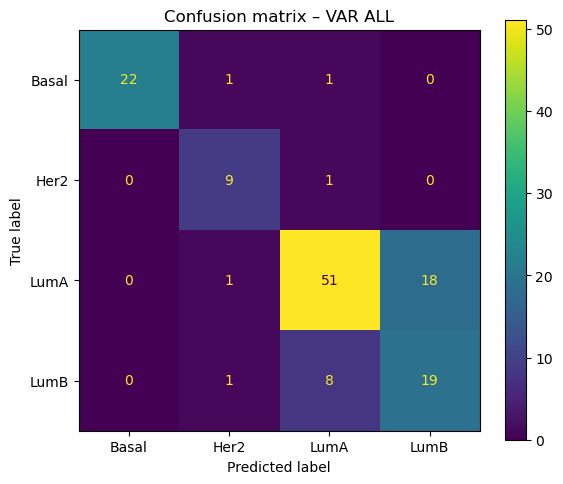


Loading MOFA model: var_intersection from exports\mofa_var_Kperview_intersection.hdf5
Factors shape: (401, 15)
Fitting 5 folds for each of 10 candidates, totalling 50 fits

[VAR INTERSECTION]
Best params: {'clf__C': 0.01, 'clf__penalty': 'l2'}
CV balanced accuracy (mean ± std): 0.816 ± 0.046
Test balanced accuracy: 0.679
Test accuracy:          0.716
Test ROC-AUC (OvR, w):  0.887

Classification report:
              precision    recall  f1-score   support

       Basal      0.909     0.833     0.870        12
        Her2      0.400     0.667     0.500         6
        LumA      0.822     0.804     0.813        46
        LumB      0.467     0.412     0.438        17

    accuracy                          0.716        81
   macro avg      0.649     0.679     0.655        81
weighted avg      0.729     0.716     0.719        81



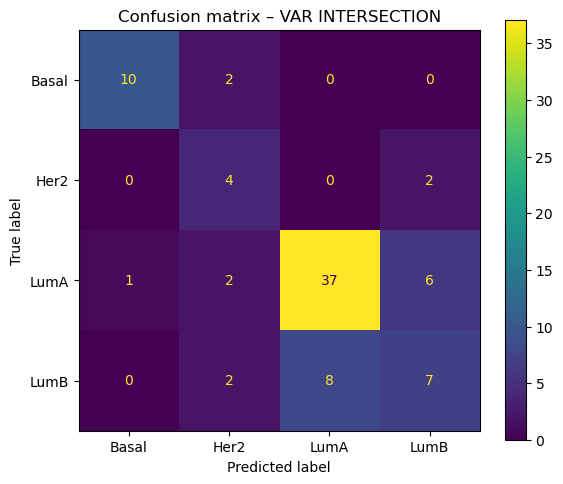


Loading MOFA model: anova_all from exports\mofa_anova_Kperview_all.hdf5
Factors shape: (658, 15)
Fitting 5 folds for each of 10 candidates, totalling 50 fits

[ANOVA ALL]
Best params: {'clf__C': 0.1, 'clf__penalty': 'l1'}
CV balanced accuracy (mean ± std): 0.802 ± 0.029
Test balanced accuracy: 0.784
Test accuracy:          0.750
Test ROC-AUC (OvR, w):  0.899

Classification report:
              precision    recall  f1-score   support

       Basal      0.885     0.958     0.920        24
        Her2      0.800     0.800     0.800        10
        LumA      0.831     0.700     0.760        70
        LumB      0.514     0.679     0.585        28

    accuracy                          0.750       132
   macro avg      0.757     0.784     0.766       132
weighted avg      0.771     0.750     0.755       132



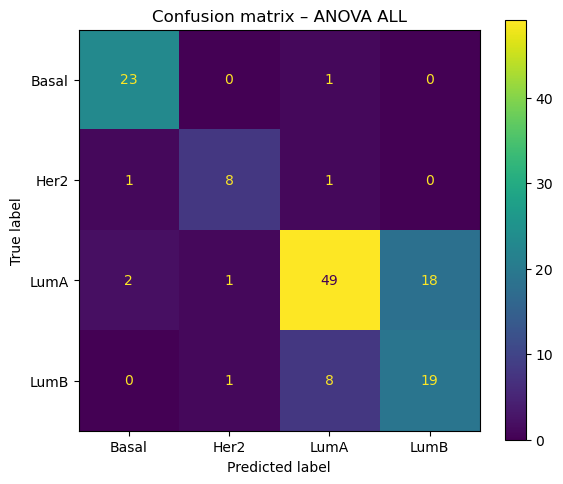


Loading MOFA model: anova_intersection from exports\mofa_anova_Kperview_intersection.hdf5
Factors shape: (401, 15)
Fitting 5 folds for each of 10 candidates, totalling 50 fits

[ANOVA INTERSECTION]
Best params: {'clf__C': 0.1, 'clf__penalty': 'l1'}
CV balanced accuracy (mean ± std): 0.843 ± 0.059
Test balanced accuracy: 0.800
Test accuracy:          0.790
Test ROC-AUC (OvR, w):  0.903

Classification report:
              precision    recall  f1-score   support

       Basal      0.917     0.917     0.917        12
        Her2      0.714     0.833     0.769         6
        LumA      0.860     0.804     0.831        46
        LumB      0.579     0.647     0.611        17

    accuracy                          0.790        81
   macro avg      0.768     0.800     0.782        81
weighted avg      0.799     0.790     0.793        81



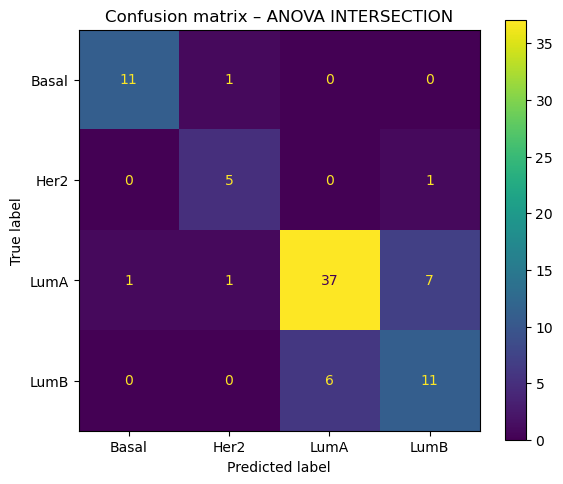

,title,mean_cv_bal_acc,std_cv_bal_acc,test_bal_acc,test_acc,test_roc_auc_ovr
0,VAR ALL,0.814763,0.008616,0.805952,0.765152,0.911624
1,VAR INTERSECTION,0.815951,0.045642,0.679028,0.716049,0.886647
2,ANOVA ALL,0.802375,0.029200,0.784226,0.750000,0.899032
3,ANOVA INTERSECTION,0.843295,0.058751,0.800352,0.790123,0.903307


In [11]:
results = []

for key, path in MODEL_FILES.items():
    print("\n" + "=" * 80)
    print(f"Loading MOFA model: {key} from {path}")
    model = mofa.mofa_model(path)

    # factors as DataFrame
    # index: sample IDs, columns: Factor1,...,FactorK
    factors_df = model.get_factors(df=True)  # docs: df=True -> DataFrame

    print("Factors shape:", factors_df.shape)

    res = run_logreg_on_factors(
        X_factors=factors_df,
        labels_any=pam_any,
        title=key.replace("_", " ").upper(),
        verbose=True,
    )
    results.append(res)

# Summary table
results_df = pd.DataFrame(results)
results_df


In [12]:
import os
import muon as mu

# ---------------------------------------------------------
# Configuration for this specific MOFA run
# ---------------------------------------------------------
N_KEEP_PER_VIEW_2000 = {
    "mRNA": 2000,   # K1
    "DNAm": 2000,   # K2
    "RPPA": 464,    # K3
}

EXPORT_DIR = "exports"
os.makedirs(EXPORT_DIR, exist_ok=True)

outfile = os.path.join(EXPORT_DIR, "mofa_var_K2000_2000_464_all.hdf5")
MOFA_N_FACTORS = 15

print(">>> Selecting most variable features with K1=2000, K2=2000, K3=464")

filtered_data_2000, feat_idx_2000 = select_top_variable_features_per_view(
    data,
    n_keep_per_view=N_KEEP_PER_VIEW_2000,
    views=["mRNA", "DNAm", "RPPA"],
    use="var",   # or "mad" if you want median absolute deviation
)

print("\n>>> Building MuData for ALL patients (union of samples)")
mdata_2000_all = build_mdata_from_filtered_views(
    filtered_data=filtered_data_2000,
    full_data=data,
    views=["mRNA", "DNAm", "RPPA"],
    patient_mode="all",   # change to "intersection" if you want only overlapping
)

print("  - Samples:", mdata_2000_all.n_obs)
for mod_key in mdata_2000_all.mod:
    print(f"    {mod_key}: {mdata_2000_all[mod_key].X.shape}")

print("\n>>> Training MOFA with 15 factors for this config...")
mu.tl.mofa(
    mdata_2000_all,
    use_obs="union",
    n_factors=MOFA_N_FACTORS,
    convergence_mode="medium",
    outfile=outfile,
)

print(f"\n>>> DONE. Saved MOFA model to: {outfile}")


>>> Selecting most variable features with K1=2000, K2=2000, K3=464
mRNA: kept 2000 / 29995 features (most variable, var)
DNAm: kept 2000 / 100000 features (most variable, var)
RPPA: kept 464 / 464 features (most variable, var)

>>> Building MuData for ALL patients (union of samples)
  - Samples: 658
    rna: (658, 2000)
    dna: (658, 2000)
    rppa: (658, 464)

>>> Training MOFA with 15 factors for this config...

        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        #########################################

Loading MOFA model from: exports\mofa_var_K2000_2000_464_all.hdf5
Factors shape: (658, 15)
After dropping missing labels:
  X shape: (658, 15)
  y shape: (658,)

Train / test sizes:
  X_train: (526, 15)   X_test: (132, 15)

>>> Fitting GridSearchCV (logreg on MOFA factors)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best hyperparameters: {'clf__C': 1, 'clf__penalty': 'l1'}
CV balanced accuracy (mean ± std): 0.811 ± 0.023

Test balanced accuracy: 0.824
Test accuracy:          0.811
Test ROC-AUC (OvR, w):  0.938

Classification report:
              precision    recall  f1-score   support

       Basal      0.920     0.958     0.939        24
        Her2      0.900     0.900     0.900        10
        LumA      0.841     0.829     0.835        70
        LumB      0.607     0.607     0.607        28

    accuracy                          0.811       132
   macro avg      0.817     0.824     0.820       132
weighted avg      0.810     0.811     0.810       132



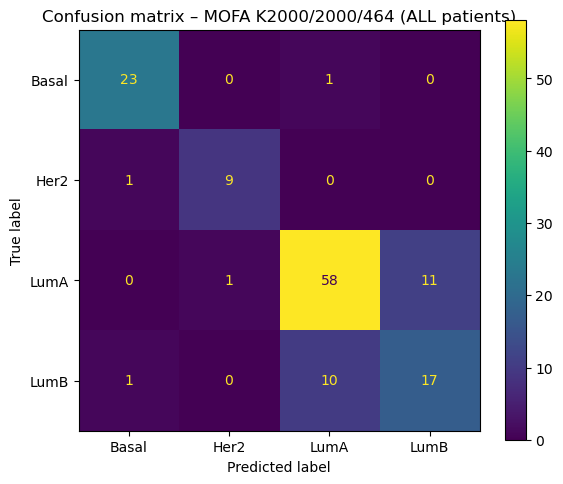

In [13]:
import os
import mofax as mofa
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    accuracy_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

# --------------------------------------------------------------------
# 1) Load MOFA model (K1=2000, K2=2000, K3=464, ALL patients)
# --------------------------------------------------------------------
MODEL_PATH = os.path.join("exports", "mofa_var_K2000_2000_464_all.hdf5")

print(f"Loading MOFA model from: {MODEL_PATH}")
model = mofa.mofa_model(MODEL_PATH)

# Factors as DataFrame: rows = samples, columns = Factor1..FactorK
X_factors = model.get_factors(df=True)
print("Factors shape:", X_factors.shape)

# --------------------------------------------------------------------
# 2) Align factors with PAM50_any labels
# --------------------------------------------------------------------
y_any = pam_any.reindex(X_factors.index)
mask = y_any.notna()

X = X_factors.loc[mask]
y = y_any.loc[mask]

print("After dropping missing labels:")
print("  X shape:", X.shape)
print("  y shape:", y.shape)

# encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)

# --------------------------------------------------------------------
# 3) Train / test split
# --------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_enc,
    test_size=0.2,
    stratify=y_enc,
    random_state=42,
)

print("\nTrain / test sizes:")
print("  X_train:", X_train.shape, "  X_test:", X_test.shape)

# --------------------------------------------------------------------
# 4) Pipeline + GridSearchCV over Logistic Regression
# --------------------------------------------------------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        solver="saga",
        multi_class="multinomial",
        max_iter=5000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42,
    )),
])

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__penalty": ["l1", "l2"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    pipe,
    param_grid,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True,
)

print("\n>>> Fitting GridSearchCV (logreg on MOFA factors)...")
gs.fit(X_train, y_train)

best_idx = gs.best_index_
mean_cv = gs.cv_results_["mean_test_score"][best_idx]
std_cv = gs.cv_results_["std_test_score"][best_idx]

print("\nBest hyperparameters:", gs.best_params_)
print(f"CV balanced accuracy (mean ± std): {mean_cv:.3f} ± {std_cv:.3f}")

# --------------------------------------------------------------------
# 5) Evaluate on test set
# --------------------------------------------------------------------
y_pred = gs.predict(X_test)
proba = gs.predict_proba(X_test)

bal_acc_test = balanced_accuracy_score(y_test, y_pred)
acc_test = accuracy_score(y_test, y_pred)
roc_auc_ovr = roc_auc_score(y_test, proba, multi_class="ovr", average="weighted")

print(f"\nTest balanced accuracy: {bal_acc_test:.3f}")
print(f"Test accuracy:          {acc_test:.3f}")
print(f"Test ROC-AUC (OvR, w):  {roc_auc_ovr:.3f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3, target_names=le.classes_))

# --------------------------------------------------------------------
# 6) Confusion matrix
# --------------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap="viridis", colorbar=True)
ax.grid(False)
plt.title("Confusion matrix – MOFA K2000/2000/464 (ALL patients)")
plt.tight_layout()
plt.show()
